<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Hysteresis_Calculation_with_Adjacency_and_CuPy_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install -q cupy-cuda12x matplotlib

CUDA device: Tesla T4
Macrospin nodes: 1,728
Graph edges evaluated per node: 12

Fe16N2 adjacency hysteresis summary
-----------------------------------
Experimental Ms target       : 168.0 emu/g
Experimental Hc target       : 2.650 kOe
Effective Ku                 : 0.410 MJ/m^3
Mean anisotropy field mu0 Hk : 0.660 T
Simulated Hc                 : 2.613 kOe
Simulated mu0 Hc             : 0.261 T
Simulated Mr                 : 81.34 emu/g
Mr / Ms                      : 0.484
Loop energy density          : 791.18 kJ/m^3


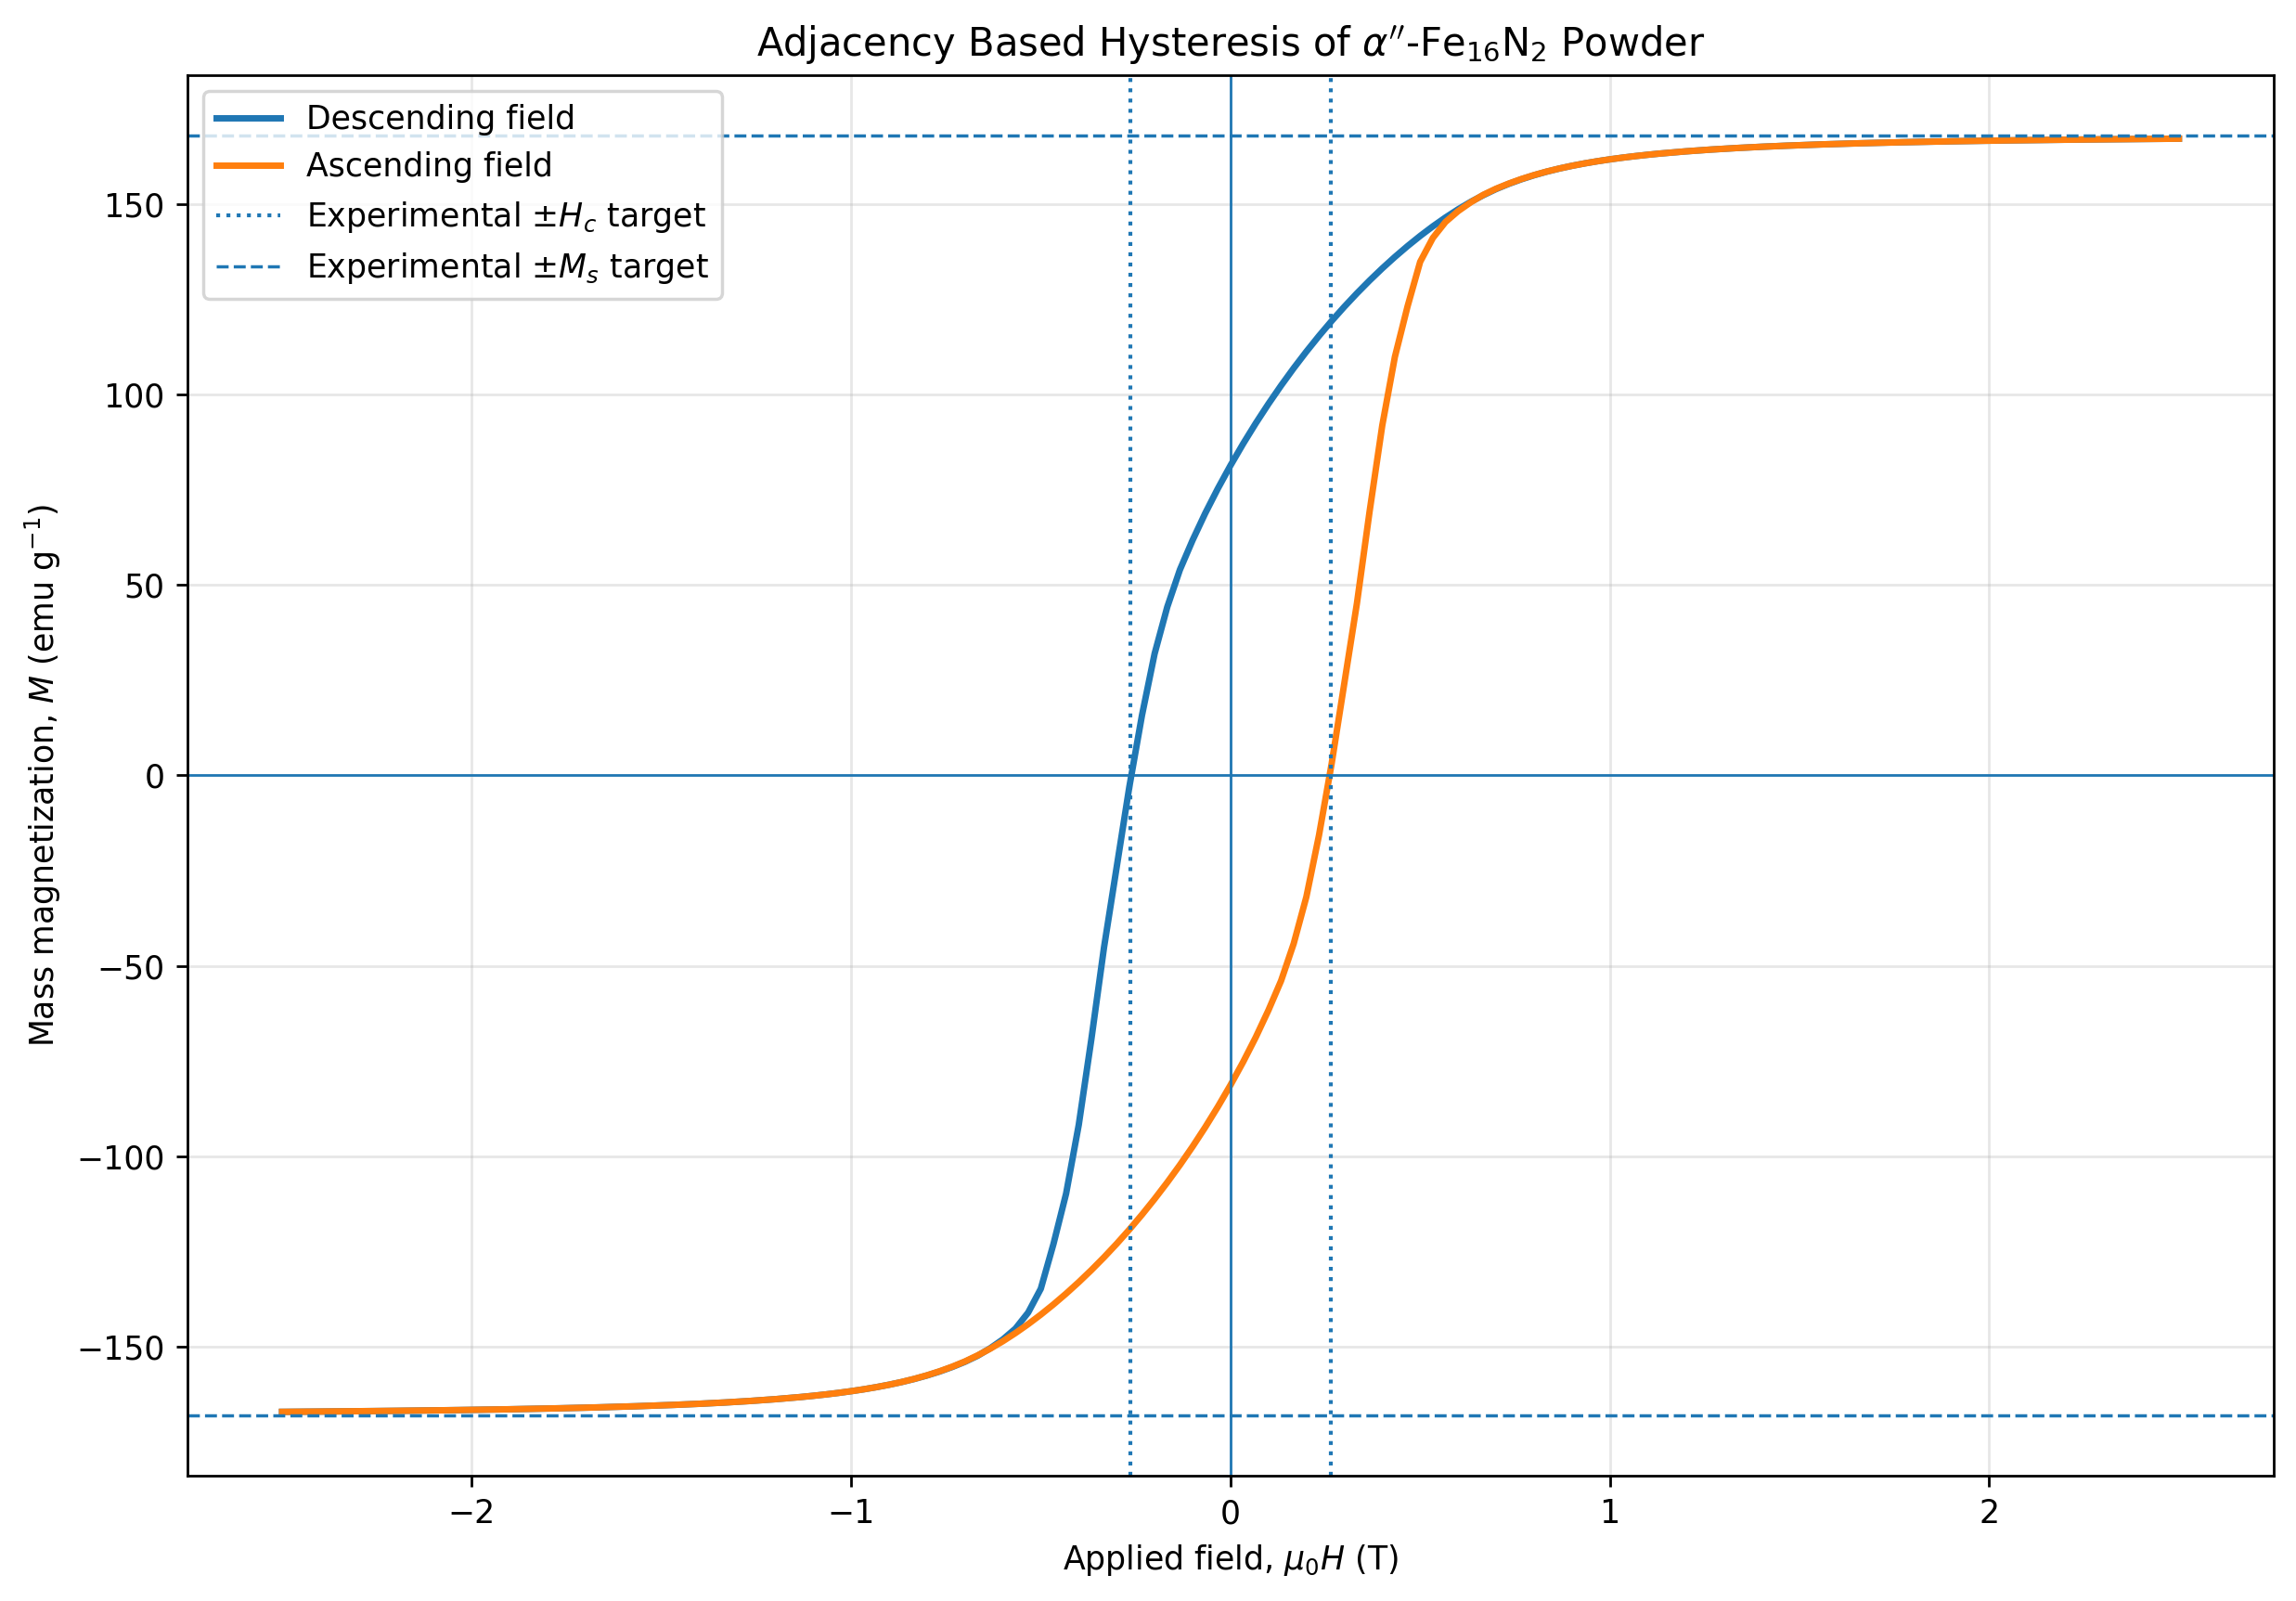

In [ ]:
"""Simulate hysteresis in Fe16N2 magnetic powder on a GPU.

Powder is represented as a three-dimensional graph of magnetic
macrospins. Nearest-neighbor graph edges carry truncated dipolar
interactions, and each node has a randomly oriented uniaxial easy axis.

The applied magnetic field is swept quasistatically in both directions.
At every field point, the macrospins undergo dissipative Landau-Lifshitz
relaxation toward a local metastable state.
"""

import math

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------

# Reproducibility
RANDOM_SEED = 7

# Fe16N2 material calibration
EXPERIMENTAL_MS_EMU_G = 168.0
EXPERIMENTAL_HC_KOE = 2.65

DENSITY_KG_M3 = 7_430.0

# Effective powder anisotropy.
#
# The intrinsic crystalline scale can approach approximately
# 1 MJ/m^3. A lower effective value captures powder-scale
# reversal, disorder, dipolar coupling, and local defects.
EFFECTIVE_KU_J_M3 = 0.410e6
KU_LOG_SCATTER = 0.15

# Magnetic graph dimensions
LATTICE_SIDE = 12
NEIGHBORS_PER_NODE = 12
KNN_CHUNK_SIZE = 512

# Geometric surrogate for the powder
MEAN_PARTICLE_DIAMETER_NM = 35.0
PARTICLE_DIAMETER_LOG_SCATTER = 0.08
MEAN_CENTER_SPACING_NM = 45.0
POSITION_JITTER_FRACTION = 0.05
MINIMUM_SEPARATION_FACTOR = 1.02

# Strength multiplier for adjacency dipolar interactions.
#
# 0.0 -> independent random-axis macrospins
# 1.0 -> physical nearest-neighbor dipolar estimate
DIPOLAR_COUPLING_SCALE = 1.0

# Optional phenomenological contact coupling.
#
# Keep at zero for loose powder. Positive values can represent
# additional alignment in strongly contacting or compacted powder.
GRAPH_EXCHANGE_MU0_H_T = 0.0

# Magnetic-field sweep
FIELD_MAX_T = 2.5
FIELD_POINTS_PER_BRANCH = 151

# Local relaxation controls
RELAXATION_STEPS = 90
RELAXATION_GAIN = 0.35
MAX_ROTATION_PER_STEP_RAD = 0.10
FIELD_NORM_FLOOR_A_M = 2.0e4
INITIAL_TILT = 1.0e-3

# Numerical precision
GPU_DTYPE = cp.float32

# Figure configuration
FIGURE_WIDTH_INCHES = 10.0
FIGURE_HEIGHT_INCHES = 7.0
FIGURE_DPI = 250
LINE_WIDTH = 2.0
GRID_ALPHA = 0.30

SAVE_FIGURE = False
FIGURE_FILENAME = "fe16n2_powder_hysteresis.png"


# ------------------------------------------------------------
# PHYSICAL CONSTANTS AND DERIVED VALUES
# ------------------------------------------------------------

MU_0 = 4.0e-7 * math.pi

# 1 emu/g = 1 A m^2/kg.
#
# Multiplication by density converts mass magnetization into
# volumetric magnetization in A/m.
MS_A_M = EXPERIMENTAL_MS_EMU_G * DENSITY_KG_M3

EXPERIMENTAL_HC_T = 0.1 * EXPERIMENTAL_HC_KOE

GRAPH_EXCHANGE_H_A_M = GRAPH_EXCHANGE_MU0_H_T / MU_0

PARTICLE_COUNT = LATTICE_SIDE**3


# ------------------------------------------------------------
# MATPLOTLIB CONFIGURATION
# ------------------------------------------------------------

plt.rcParams.update(
    {
        "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI,
        "font.family": "DejaVu Sans",
        "axes.grid": True,
        "grid.alpha": GRID_ALPHA,
    }
)


# ------------------------------------------------------------
# VECTOR UTILITIES
# ------------------------------------------------------------

def normalize_vectors(vectors):
    """Normalize a collection of three-dimensional vectors.

    Args:
        vectors: CuPy array with final dimension equal to three.

    Returns:
        CuPy array containing unit vectors.
    """
    norms = cp.linalg.norm(vectors, axis=-1, keepdims=True)
    norms = cp.maximum(norms, cp.asarray(1.0e-20, dtype=GPU_DTYPE))

    return vectors / norms


def gpu_name():
    """Return the CUDA device name."""
    properties = cp.cuda.runtime.getDeviceProperties(0)
    name = properties["name"]

    if isinstance(name, bytes):
        name = name.decode("utf-8")

    return name


# ------------------------------------------------------------
# POWDER GEOMETRY
# ------------------------------------------------------------

def create_powder_nodes(random_state):
    """Create a jittered three-dimensional surrogate powder packing.

    The regular seed lattice controls the minimum center separation,
    and small random displacements remove exact cubic symmetry.

    Args:
        random_state: CuPy random-state object.

    Returns:
        Tuple containing positions, particle diameters, and volumes.
    """
    coordinates = cp.arange(LATTICE_SIDE, dtype=GPU_DTYPE)

    x_grid, y_grid, z_grid = cp.meshgrid(
        coordinates,
        coordinates,
        coordinates,
        indexing="ij",
    )

    positions = cp.stack(
        (x_grid.ravel(), y_grid.ravel(), z_grid.ravel()),
        axis=1,
    )

    jitter = random_state.standard_normal(
        positions.shape,
        dtype=GPU_DTYPE,
    )

    positions += POSITION_JITTER_FRACTION * jitter

    spacing_m = MEAN_CENTER_SPACING_NM * 1.0e-9
    positions *= spacing_m

    diameter_noise = random_state.standard_normal(
        PARTICLE_COUNT,
        dtype=GPU_DTYPE,
    )

    diameters_m = (
        MEAN_PARTICLE_DIAMETER_NM
        * 1.0e-9
        * cp.exp(
            PARTICLE_DIAMETER_LOG_SCATTER * diameter_noise
        )
    )

    volumes_m3 = (
        math.pi
        / 6.0
        * diameters_m**3
    )

    return positions, diameters_m, volumes_m3


# ------------------------------------------------------------
# GPU ADJACENCY CONSTRUCTION
# ------------------------------------------------------------

def build_knn_graph(positions):
    """Construct a k-nearest-neighbor adjacency graph on the GPU.

    Chunking limits temporary pair-distance memory, allowing the
    node count to increase without storing a complete N x N x 3
    displacement tensor.

    Args:
        positions: Particle positions with shape (N, 3).

    Returns:
        Integer neighbor array with shape (N, k).
    """
    node_count = positions.shape[0]

    neighbors = cp.empty(
        (node_count, NEIGHBORS_PER_NODE),
        dtype=cp.int32,
    )

    for start in range(0, node_count, KNN_CHUNK_SIZE):
        stop = min(start + KNN_CHUNK_SIZE, node_count)

        difference = (
            positions[start:stop, None, :]
            - positions[None, :, :]
        )

        distance_squared = cp.sum(
            difference * difference,
            axis=2,
        )

        local_rows = cp.arange(stop - start)
        global_rows = cp.arange(start, stop)

        distance_squared[local_rows, global_rows] = cp.inf

        nearest = cp.argpartition(
            distance_squared,
            kth=NEIGHBORS_PER_NODE - 1,
            axis=1,
        )[:, :NEIGHBORS_PER_NODE]

        neighbors[start:stop] = nearest.astype(cp.int32)

    return neighbors


# ------------------------------------------------------------
# ADJACENCY DIPOLAR TENSOR
# ------------------------------------------------------------

def build_dipolar_tensor(
    positions,
    diameters_m,
    volumes_m3,
    neighbors,
):
    """Precompute dipolar coupling tensors for every graph edge.

    The resulting tensor converts neighboring unit macrospins
    directly into local magnetic fields in A/m.

    Args:
        positions: Node positions in meters.
        diameters_m: Magnetic particle diameters.
        volumes_m3: Magnetic particle volumes.
        neighbors: Nearest-neighbor adjacency array.

    Returns:
        Dipolar tensor with shape (N, k, 3, 3).
    """
    neighbor_positions = positions[neighbors]

    displacement = (
        neighbor_positions
        - positions[:, None, :]
    )

    distance = cp.linalg.norm(
        displacement,
        axis=2,
    )

    neighbor_diameters = diameters_m[neighbors]

    minimum_distance = (
        0.5
        * (
            diameters_m[:, None]
            + neighbor_diameters
        )
        * MINIMUM_SEPARATION_FACTOR
    )

    safe_distance = cp.maximum(
        distance,
        minimum_distance,
    )

    r_hat = (
        displacement
        / safe_distance[:, :, None]
    )

    neighbor_volumes = volumes_m3[neighbors]

    prefactor = (
        DIPOLAR_COUPLING_SCALE
        * MS_A_M
        * neighbor_volumes
        / (
            4.0
            * math.pi
            * safe_distance**3
        )
    )

    outer_product = (
        r_hat[:, :, :, None]
        * r_hat[:, :, None, :]
    )

    identity = cp.eye(
        3,
        dtype=GPU_DTYPE,
    )[None, None, :, :]

    dipolar_tensor = (
        prefactor[:, :, None, None]
        * (
            3.0 * outer_product
            - identity
        )
    )

    return dipolar_tensor.astype(GPU_DTYPE)


# ------------------------------------------------------------
# MAGNETIC MICROSTATE
# ------------------------------------------------------------

def create_magnetic_state(random_state):
    """Create random easy axes and anisotropy fields.

    Args:
        random_state: CuPy random-state object.

    Returns:
        Tuple containing easy axes and anisotropy field amplitudes.
    """
    easy_axes = random_state.standard_normal(
        (PARTICLE_COUNT, 3),
        dtype=GPU_DTYPE,
    )

    easy_axes = normalize_vectors(easy_axes)

    anisotropy_noise = random_state.standard_normal(
        PARTICLE_COUNT,
        dtype=GPU_DTYPE,
    )

    local_ku = (
        EFFECTIVE_KU_J_M3
        * cp.exp(
            KU_LOG_SCATTER
            * anisotropy_noise
        )
    )

    anisotropy_field = (
        2.0
        * local_ku
        / (
            MU_0
            * MS_A_M
        )
    )

    return easy_axes, anisotropy_field


def initial_positive_saturation(random_state):
    """Create a nearly saturated positive-z macrospin state.

    Args:
        random_state: CuPy random-state object.

    Returns:
        Initial macrospin array with shape (N, 3).
    """
    magnetization = cp.zeros(
        (PARTICLE_COUNT, 3),
        dtype=GPU_DTYPE,
    )

    magnetization[:, 2] = 1.0

    perturbation = random_state.standard_normal(
        magnetization.shape,
        dtype=GPU_DTYPE,
    )

    magnetization += INITIAL_TILT * perturbation

    return normalize_vectors(magnetization)


# ------------------------------------------------------------
# EFFECTIVE FIELD
# ------------------------------------------------------------

def calculate_effective_field(
    magnetization,
    applied_h_a_m,
    easy_axes,
    anisotropy_field,
    neighbors,
    dipolar_tensor,
):
    """Calculate the local effective field at every graph node.

    Args:
        magnetization: Unit macrospin array.
        applied_h_a_m: External H field along z in A/m.
        easy_axes: Local uniaxial easy-axis vectors.
        anisotropy_field: Local anisotropy field amplitudes.
        neighbors: Graph adjacency array.
        dipolar_tensor: Precomputed graph dipolar tensors.

    Returns:
        Effective field array in A/m.
    """
    easy_axis_projection = cp.sum(
        magnetization * easy_axes,
        axis=1,
    )

    anisotropy = (
        anisotropy_field[:, None]
        * easy_axis_projection[:, None]
        * easy_axes
    )

    neighbor_magnetization = magnetization[neighbors]

    dipolar = cp.einsum(
        "nkab,nkb->na",
        dipolar_tensor,
        neighbor_magnetization,
    )

    effective_field = anisotropy + dipolar

    if GRAPH_EXCHANGE_H_A_M > 0.0:
        graph_mean = cp.mean(
            neighbor_magnetization,
            axis=1,
        )

        effective_field += (
            GRAPH_EXCHANGE_H_A_M
            * graph_mean
        )

    effective_field[:, 2] += applied_h_a_m

    return effective_field


# ------------------------------------------------------------
# DAMPED LANDau-LIFSHITZ RELAXATION
# ------------------------------------------------------------

def relax_macrospins(
    magnetization,
    applied_h_a_m,
    easy_axes,
    anisotropy_field,
    neighbors,
    dipolar_tensor,
):
    """Relax all macrospins at one quasistatic field value.

    The update follows the transverse, dissipative component of
    Landau-Lifshitz dynamics. An adaptive angular increment improves
    numerical stability over the full field sweep.

    Args:
        magnetization: Current macrospin state.
        applied_h_a_m: External field in A/m.
        easy_axes: Local easy-axis vectors.
        anisotropy_field: Local anisotropy field amplitudes.
        neighbors: Graph adjacency array.
        dipolar_tensor: Precomputed dipolar interaction tensor.

    Returns:
        Relaxed macrospin array.
    """
    for _ in range(RELAXATION_STEPS):
        effective_field = calculate_effective_field(
            magnetization,
            applied_h_a_m,
            easy_axes,
            anisotropy_field,
            neighbors,
            dipolar_tensor,
        )

        longitudinal_projection = cp.sum(
            magnetization * effective_field,
            axis=1,
            keepdims=True,
        )

        transverse_field = (
            effective_field
            - longitudinal_projection
            * magnetization
        )

        transverse_norm = cp.linalg.norm(
            transverse_field,
            axis=1,
            keepdims=True,
        )

        effective_norm = cp.linalg.norm(
            effective_field,
            axis=1,
            keepdims=True,
        )

        direction = (
            transverse_field
            / cp.maximum(
                transverse_norm,
                cp.asarray(
                    1.0e-20,
                    dtype=GPU_DTYPE,
                ),
            )
        )

        angular_step = cp.minimum(
            MAX_ROTATION_PER_STEP_RAD,
            RELAXATION_GAIN
            * transverse_norm
            / cp.maximum(
                effective_norm,
                FIELD_NORM_FLOOR_A_M,
            ),
        )

        magnetization = normalize_vectors(
            magnetization
            + angular_step
            * direction
        )

    return magnetization


# ------------------------------------------------------------
# FIELD SWEEP
# ------------------------------------------------------------

def sweep_branch(
    magnetization,
    applied_b_t,
    easy_axes,
    anisotropy_field,
    neighbors,
    dipolar_tensor,
    volumes_m3,
):
    """Sweep one branch of the hysteresis loop.

    Args:
        magnetization: Initial macrospin state.
        applied_b_t: Applied mu_0 H field values in tesla.
        easy_axes: Local easy-axis vectors.
        anisotropy_field: Local anisotropy fields.
        neighbors: Graph adjacency.
        dipolar_tensor: Graph dipolar interactions.
        volumes_m3: Node magnetic volumes.

    Returns:
        Final microstate and mass magnetization branch.
    """
    branch_magnetization = cp.empty(
        applied_b_t.size,
        dtype=GPU_DTYPE,
    )

    total_volume = cp.sum(volumes_m3)

    for field_index, field_t in enumerate(applied_b_t):
        applied_h_a_m = float(field_t) / MU_0

        magnetization = relax_macrospins(
            magnetization,
            applied_h_a_m,
            easy_axes,
            anisotropy_field,
            neighbors,
            dipolar_tensor,
        )

        volume_weighted_mz = (
            cp.sum(
                volumes_m3
                * magnetization[:, 2]
            )
            / total_volume
        )

        branch_magnetization[field_index] = (
            EXPERIMENTAL_MS_EMU_G
            * volume_weighted_mz
        )

    return magnetization, cp.asnumpy(branch_magnetization)


# ------------------------------------------------------------
# LOOP METRICS
# ------------------------------------------------------------

def interpolate_zero_crossing(x_values, y_values):
    """Interpolate the first y = 0 crossing.

    Args:
        x_values: One-dimensional x coordinates.
        y_values: One-dimensional y coordinates.

    Returns:
        Interpolated x coordinate of the zero crossing.
    """
    products = (
        y_values[:-1]
        * y_values[1:]
    )

    crossing_indices = np.where(
        products <= 0.0
    )[0]

    if crossing_indices.size == 0:
        return np.nan

    index = crossing_indices[0]

    x_0 = x_values[index]
    x_1 = x_values[index + 1]

    y_0 = y_values[index]
    y_1 = y_values[index + 1]

    if abs(y_1 - y_0) < 1.0e-15:
        return 0.5 * (x_0 + x_1)

    return (
        x_0
        - y_0
        * (x_1 - x_0)
        / (y_1 - y_0)
    )


def interpolate_at_zero_field(
    field_t,
    magnetization,
):
    """Interpolate magnetization at zero applied field.

    Args:
        field_t: Applied field values.
        magnetization: Magnetization values.

    Returns:
        Magnetization at zero field.
    """
    ordering = np.argsort(field_t)

    return np.interp(
        0.0,
        field_t[ordering],
        magnetization[ordering],
    )


# ------------------------------------------------------------
# MAIN GPU SIMULATION
# ------------------------------------------------------------

random_state = cp.random.RandomState(
    RANDOM_SEED
)

print(f"CUDA device: {gpu_name()}")
print(f"Macrospin nodes: {PARTICLE_COUNT:,}")
print(
    "Graph edges evaluated per node: "
    f"{NEIGHBORS_PER_NODE}"
)

positions, diameters_m, volumes_m3 = (
    create_powder_nodes(
        random_state
    )
)

neighbors = build_knn_graph(
    positions
)

dipolar_tensor = build_dipolar_tensor(
    positions,
    diameters_m,
    volumes_m3,
    neighbors,
)

easy_axes, anisotropy_field = (
    create_magnetic_state(
        random_state
    )
)

magnetization = initial_positive_saturation(
    random_state
)

descending_field_t = np.linspace(
    FIELD_MAX_T,
    -FIELD_MAX_T,
    FIELD_POINTS_PER_BRANCH,
)

ascending_field_t = np.linspace(
    -FIELD_MAX_T,
    FIELD_MAX_T,
    FIELD_POINTS_PER_BRANCH,
)

magnetization, descending_m = sweep_branch(
    magnetization,
    descending_field_t,
    easy_axes,
    anisotropy_field,
    neighbors,
    dipolar_tensor,
    volumes_m3,
)

magnetization, ascending_m = sweep_branch(
    magnetization,
    ascending_field_t,
    easy_axes,
    anisotropy_field,
    neighbors,
    dipolar_tensor,
    volumes_m3,
)


# ------------------------------------------------------------
# EXTRACT COERCIVITY AND REMANENCE
# ------------------------------------------------------------

hc_descending_t = interpolate_zero_crossing(
    descending_field_t,
    descending_m,
)

hc_ascending_t = interpolate_zero_crossing(
    ascending_field_t,
    ascending_m,
)

simulated_hc_t = 0.5 * (
    abs(hc_descending_t)
    + abs(hc_ascending_t)
)

simulated_hc_koe = (
    simulated_hc_t / 0.1
)

mr_descending = interpolate_at_zero_field(
    descending_field_t,
    descending_m,
)

mr_ascending = interpolate_at_zero_field(
    ascending_field_t,
    ascending_m,
)

simulated_mr = 0.5 * (
    abs(mr_descending)
    + abs(mr_ascending)
)

squareness = (
    simulated_mr
    / EXPERIMENTAL_MS_EMU_G
)


# ------------------------------------------------------------
# HYSTERESIS ENERGY DENSITY
# ------------------------------------------------------------

loop_field_t = np.concatenate(
    (
        descending_field_t,
        ascending_field_t[1:],
    )
)

loop_mass_m = np.concatenate(
    (
        descending_m,
        ascending_m[1:],
    )
)

loop_volume_m = (
    loop_mass_m
    / EXPERIMENTAL_MS_EMU_G
    * MS_A_M
)

loop_energy_j_m3 = abs(
    np.trapezoid(
        loop_volume_m,
        loop_field_t,
    )
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

mean_hk_t = float(
    cp.asnumpy(
        MU_0
        * cp.mean(anisotropy_field)
    )
)

print()
print("Fe16N2 adjacency hysteresis summary")
print("-----------------------------------")
print(
    f"Experimental Ms target       : "
    f"{EXPERIMENTAL_MS_EMU_G:.1f} emu/g"
)
print(
    f"Experimental Hc target       : "
    f"{EXPERIMENTAL_HC_KOE:.3f} kOe"
)
print(
    f"Effective Ku                 : "
    f"{EFFECTIVE_KU_J_M3 / 1.0e6:.3f} MJ/m^3"
)
print(
    f"Mean anisotropy field mu0 Hk : "
    f"{mean_hk_t:.3f} T"
)
print(
    f"Simulated Hc                 : "
    f"{simulated_hc_koe:.3f} kOe"
)
print(
    f"Simulated mu0 Hc             : "
    f"{simulated_hc_t:.3f} T"
)
print(
    f"Simulated Mr                 : "
    f"{simulated_mr:.2f} emu/g"
)
print(
    f"Mr / Ms                      : "
    f"{squareness:.3f}"
)
print(
    f"Loop energy density          : "
    f"{loop_energy_j_m3 / 1.0e3:.2f} kJ/m^3"
)


# ------------------------------------------------------------
# HYSTERESIS PLOT
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(
        FIGURE_WIDTH_INCHES,
        FIGURE_HEIGHT_INCHES,
    ),
    dpi=FIGURE_DPI,
)

axis.plot(
    descending_field_t,
    descending_m,
    linewidth=LINE_WIDTH,
    label="Descending field",
)

axis.plot(
    ascending_field_t,
    ascending_m,
    linewidth=LINE_WIDTH,
    label="Ascending field",
)

axis.axhline(
    0.0,
    linewidth=0.8,
)

axis.axvline(
    0.0,
    linewidth=0.8,
)

axis.axvline(
    -EXPERIMENTAL_HC_T,
    linestyle=":",
    linewidth=1.2,
    label=(
        "Experimental "
        r"$\pm H_c$ target"
    ),
)

axis.axvline(
    EXPERIMENTAL_HC_T,
    linestyle=":",
    linewidth=1.2,
)

axis.axhline(
    EXPERIMENTAL_MS_EMU_G,
    linestyle="--",
    linewidth=1.0,
    label=(
        "Experimental "
        r"$\pm M_s$ target"
    ),
)

axis.axhline(
    -EXPERIMENTAL_MS_EMU_G,
    linestyle="--",
    linewidth=1.0,
)

axis.set_xlabel(
    r"Applied field, $\mu_0 H$ (T)"
)

axis.set_ylabel(
    r"Mass magnetization, "
    r"$M$ (emu g$^{-1}$)"
)

axis.set_title(
    r"Adjacency Based Hysteresis of "
    r"$\alpha^{\prime\prime}$-Fe$_{16}$N$_2$ Powder"
)

axis.legend(
    loc="best",
    frameon=True,
)

axis.grid(
    True,
    alpha=GRID_ALPHA,
)

figure.tight_layout()

if SAVE_FIGURE:
    figure.savefig(
        FIGURE_FILENAME,
        bbox_inches="tight",
        dpi=FIGURE_DPI,
    )

plt.show()